## 1. Setup: Import Libraries

In [ ]:
import os
import io
import requests
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

# Reproducibility
np.random.seed(42)

**Prompt suggestion**: Tell me in chat what "import" does. Give me a one line senctence explaing what each imported library is for (non-technical).

## 2. Load the Data

The dataset is the **Metro Interstate Traffic Volume** dataset from the UCI Machine Learning Repository.
It contains hourly measurements from October 2012 to September 2018 on Interstate 94 westbound in Minneapolis.

| Column | Description |
|---|---|
| `holiday` | US national holiday name, or `None` |
| `temp` | Hourly temperature (Kelvin) |
| `rain_1h` | Rainfall in the past hour (mm) |
| `snow_1h` | Snowfall in the past hour (mm) |
| `clouds_all` | Cloud cover (%) |
| `weather_main` | Short description of weather |
| `date_time` | Datetime of the hourly measurement |
| `traffic_volume` | **Target**: hourly vehicle count |

The cell below will try to download the data directly from UCI and cache it locally.
If the download fails, it will prompt you to upload `ch4_data.csv` manually.

In [ ]:
UCI_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00492/Metro_Interstate_Traffic_Volume.csv.gz"
)
CACHE_FILE = "ch4_data.csv"

if os.path.exists(CACHE_FILE):
    print("Loading from local cache...")
    df = pd.read_csv(CACHE_FILE)
else:
    try:
        print("Attempting to download from UCI repository...")
        response = requests.get(UCI_URL, timeout=30)
        response.raise_for_status()
        df = pd.read_csv(BytesIO(response.content), compression="gzip")
        df.to_csv(CACHE_FILE, index=False)
        print(f"Downloaded and saved to '{CACHE_FILE}'")
    except Exception as e:
        print(f"Download failed ({e}).")
        print("Please upload 'ch4_data.csv' using the file picker below.")
        from google.colab import files
        uploaded = files.upload()
        df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
        df.to_csv(CACHE_FILE, index=False)
        print(f"File cached to '{CACHE_FILE}'")

df.info()

Attempting to download from UCI repository...
Downloaded and saved to 'ch4_data.csv'
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [ ]:
df.head(5)

**Prompt suggestion**: Tell me in non technical terms what the data is, and how it is obtained. Also, what is a "cache"?

# Now it is up to you!

You have data. You have an AI. Do something with the data! If curious, you can start by predicting traffic flows. NB: make sure you have run the cells up to here, so the AI can also see what is inside the data (the ```df.head(5)``` code in the cell above)

What approach should you use? Ask the AI for advice. Or try the prompt in the cell below.

# And then?

Run the code. If you get an error, have the AI explain it (so you can learn) and fix it (so you can see how it is fixed).

# Finally

Using code that you do not understand is dangerous. It is perfectly fine to use AI to generate code (almost all professional programmers do this already). But you still have to understand what it does and how it works, at least at some level. So your last task is get the AI to explain to you what the code does, and how it works. (It is a good idea to give it some idea of your coding background -- for instance. "I started coding in Python two weeks ago" or "I used to code quite a lot in Matlab and C, but I am new to Python.")

# If you need a challenge

Once your code is working, and you understand it -- change it! Ask the AI to implement a different approach, or use a different dataset. Much work involves modifying existing code, rather than building it from new.

**Enjoy!**

**Prompt suggestion** I would like to predict traffic flows in this dataset. Help me do this using a standard approach in machine learning. Please explain in comments what each of the steps are doing and why. A few graphs along the way would be nice. Please report the out-of-sample RMSE, so I can assess overall model performance.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Feature Engineering: Convert 'date_time' to actual numbers the model can use
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.weekday
df['is_holiday'] = (df['holiday'] != 'None').astype(int)

# We'll use temperature, clouds, hour, day of week, and holiday status as our 'clues' (features)
features = ['temp', 'clouds_all', 'hour', 'day_of_week', 'is_holiday']
X = df[features]
y = df['traffic_volume']

# 2. Split the data: 80% for learning (train), 20% for testing (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Calculate the Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Out-of-sample RMSE: {rmse:.2f} vehicles')
print('This means on average, our prediction is off by about', round(rmse), 'vehicles per hour.')

Out-of-sample RMSE: 1822.43 vehicles
This means on average, our prediction is off by about 1822 vehicles per hour.


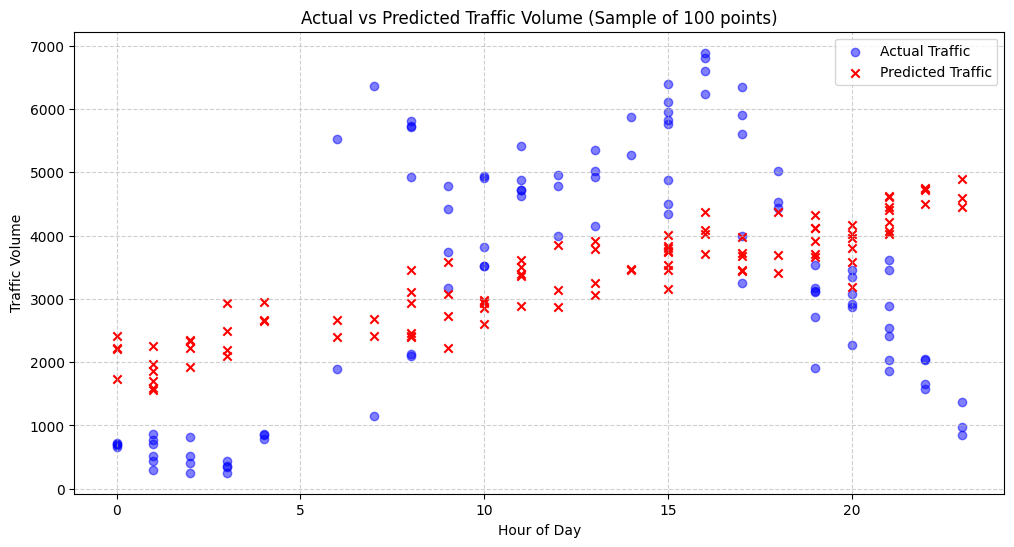

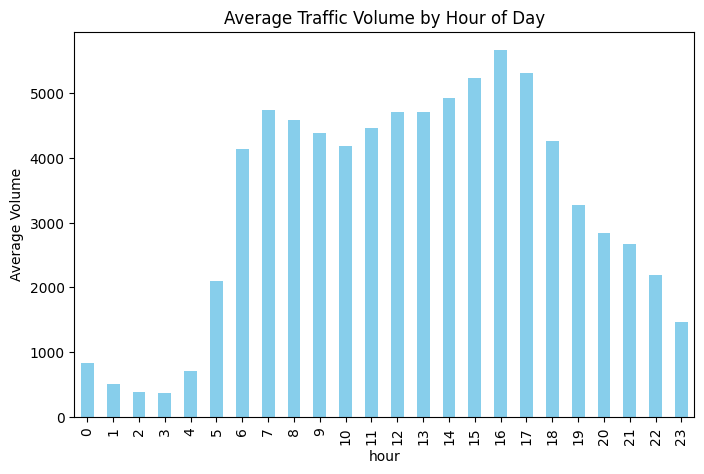

In [ ]:
plt.figure(figsize=(12, 6))

# Let's look at a small slice of the test data to see how predictions compare to reality
plt.scatter(X_test['hour'][:100], y_test[:100], color='blue', label='Actual Traffic', alpha=0.5)
plt.scatter(X_test['hour'][:100], y_pred[:100], color='red', label='Predicted Traffic', marker='x')

plt.title('Actual vs Predicted Traffic Volume (Sample of 100 points)')
plt.xlabel('Hour of Day')
plt.ylabel('Traffic Volume')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Correlation check: How much does hour actually matter?
plt.figure(figsize=(8, 5))
df.groupby('hour')['traffic_volume'].mean().plot(kind='bar', color='skyblue')
plt.title('Average Traffic Volume by Hour of Day')
plt.ylabel('Average Volume')
plt.show()

**THE END**